In [2]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
# Create the data
data = {
    'pages': [5, 12, 3, 8, 15, 4, 10, 6, 20, 7,
              9, 2, 14, 5, 11, 3, 8, 18, 6, 13,
              4, 16, 7, 10, 2, 12, 5, 9, 15, 6],

    'deadline_days': [14, 7, 21, 5, 10, 18, 6, 12, 8, 15,
                      4, 25, 9, 11, 7, 20, 6, 5, 14, 8,
                      16, 6, 10, 4, 22, 7, 13, 5, 9, 11],

    'rate_inr': [8000, 22000, 5000, 18000, 28000, 6500, 19000, 10000, 35000, 11000,
                 20000, 3500, 25000, 9000, 21000, 5500, 17000, 38000, 9500, 24000,
                 7000, 32000, 13000, 23000, 4000, 22500, 8500, 19500, 29000, 11500]
}

In [4]:
df = pd.DataFrame(data)

In [6]:
df.head()

,pages,deadline_days,rate_inr
0,5,14,8000
1,12,7,22000
2,3,21,5000
3,8,5,18000
4,15,10,28000


In [8]:
df.dtypes

pages            int64
deadline_days    int64
rate_inr         int64
dtype: object

In [10]:
df.describe()

,pages,deadline_days,rate_inr
count,30.000000,30.000000,30.000000
mean,8.833333,10.933333,16833.333333
std,4.885470,5.777085,9715.197243
min,2.000000,4.000000,3500.000000
25%,5.000000,6.250000,8625.000000
50%,8.000000,9.500000,17500.000000
75%,12.000000,14.000000,22875.000000
max,20.000000,25.000000,38000.000000


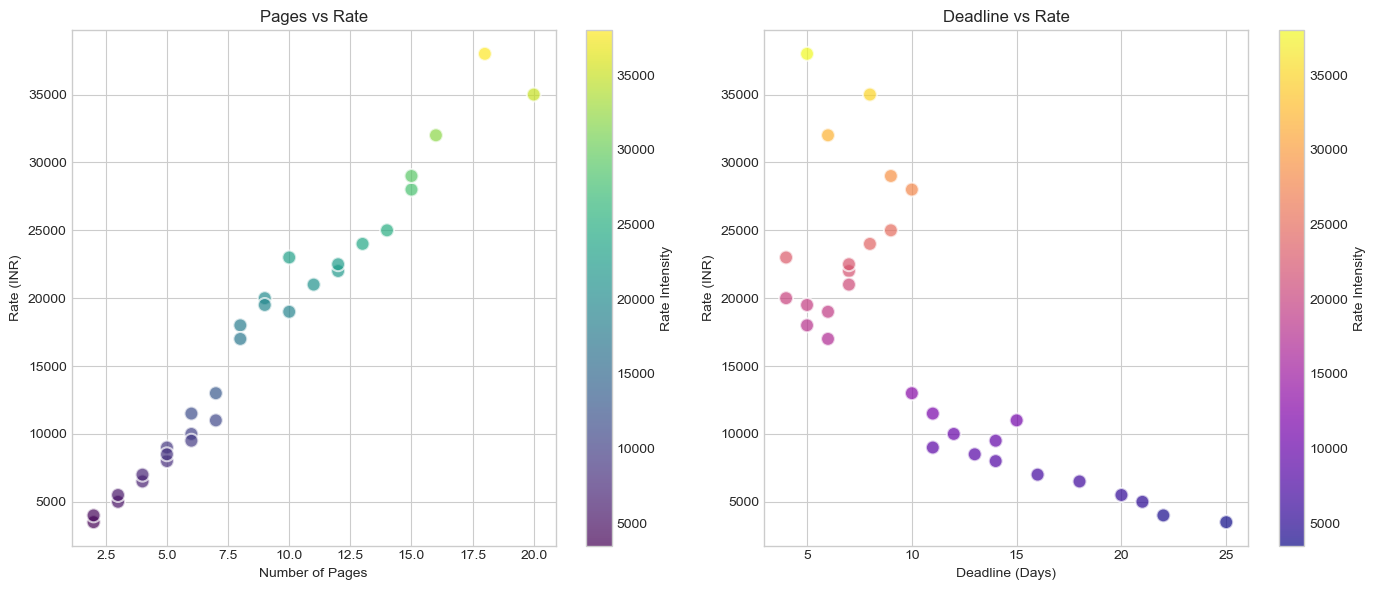

In [21]:
#Visualize the Data
plt.style.use('seaborn-v0_8-whitegrid')
fig, axis = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axis[0].scatter(df['pages'], df['rate_inr'],
                           c=df['rate_inr'], cmap='viridis', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axis[0].set_xlabel('Number of Pages')
axis[0].set_ylabel('Rate (INR)')
axis[0].set_title('Pages vs Rate')
plt.colorbar(scatter1, ax=axis[0], label='Rate Intensity')

scatter2 = axis[1].scatter(df['deadline_days'], df['rate_inr'],
                           c=df['rate_inr'], cmap='plasma', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axis[1].set_xlabel('Deadline (Days)')
axis[1].set_ylabel('Rate (INR)')
axis[1].set_title('Deadline vs Rate')
plt.colorbar(scatter2, ax=axis[1], label='Rate Intensity')

plt.tight_layout()
plt.show()

In [27]:
# Prepare data for training
X = df[['pages','deadline_days']]
y = df['rate_inr']

In [28]:
# split the data into training and testing sets
random_state = 42
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2)

In [29]:
# create and train the model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# check model parameters
pages_coeff = model.coef_[0].round()
deadline_coeff = model.coef_[1].round()
intercept = model.intercept_

In [36]:
pages_coeff, deadline_coeff, intercept

(np.float64(1786.0), np.float64(-207.0), np.float64(3117.117197413012))

In [38]:
# Make predictions on test data set
y_pred = model.predict(X_test)

In [39]:
y_pred

array([21313.8212278 ,  2129.86580498, 16369.92474319, 20149.44084059,
        9353.5206543 , 28043.8503809 ])

In [40]:
results = pd.DataFrame({'Actual':y_test.values, 'Predicted': y_pred.round()})
results

,Actual,Predicted
0,21000,21314.0
1,4000,2130.0
2,18000,16370.0
3,23000,20149.0
4,8500,9354.0
5,29000,28044.0


In [43]:
# Model accuracy 
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.9634109320332438

In [49]:
# Answer for given question
new_project = [[10,5]]
predicted_rate = model.predict(new_project)


C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [50]:
print(f"\nQuestion: 10-page website, 5-day deadline")
print(f"Predicted Recommended Rate: ₹{predicted_rate[0]:,.0f}")


Question: 10-page website, 5-day deadline
Predicted Recommended Rate: ₹19,942
